In [ ]:
import os
# import re # No longer needed
import warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
# import pandas as pd # No longer needed unless doing more complex manipulation
import matplotlib.pyplot as plt
import matplotlib # Import the main library
from scipy.interpolate import interp1d
from scipy.stats import sem # Standard error of the mean

# --- Configuration ---
base_dir = Path(r'D:\Guien MEMS Lab Final\new_method') # Use raw string for Windows paths
output_dir = base_dir / 'output_python' # Create a separate output dir
test_types = ['ss0', 'ss80', 'ts']
materials = ['cerr_117', 'cerr_158', 'ecoflex_50']
concentrations = ['10v', '20v', '30v', '40v', '50v'] # For 'cerr' types

# Create output directory
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Created/ Ensured output directory exists: {output_dir}")

# Define Colormaps (Corrected call)
n_concentrations = len(concentrations)
cmap_117 = matplotlib.colormaps.get_cmap('cool')
cmap_158 = matplotlib.colormaps.get_cmap('autumn')

# Generate discrete colors spanning the colormap range
if n_concentrations > 1:
    colors_117 = {conc: cmap_117(i / (n_concentrations - 1)) for i, conc in enumerate(concentrations)}
    colors_158 = {conc: cmap_158(i / (n_concentrations - 1)) for i, conc in enumerate(concentrations)}
elif n_concentrations == 1:
     colors_117 = {concentrations[0]: cmap_117(0.5)}
     colors_158 = {concentrations[0]: cmap_158(0.5)}
else:
     colors_117 = {}
     colors_158 = {}
color_ecoflex = 'black'

# Columns mapping
col_map = {
    'Time': 0, 'Temperature': 1, 'Storage Modulus': 2, 'Loss Modulus': 3,
    'Stress': 4, 'Tan Delta': 5, 'Frequency': 6, 'Drive Force': 7,
    'Amplitude': 8, 'Strain': 9, 'Displacement': 10, 'Static Force': 11,
    'Position': 12, 'Length': 13, 'Force': 14, 'Stiffness': 15,
    'GCA Pressure': 16,
}

# --- Function to Parse Filename (Using String Splitting) ---
def parse_filename(filename):
    """Parses filename using split('_') to extract material, concentration, test type, sample."""
    try:
        base_name = filename.removesuffix('.txt')
        parts = base_name.split('_')
        if not parts: raise ValueError("Filename empty")

        material = None; concentration = None; file_test_type = None; sample = None

        if parts[0].startswith('cerr') and len(parts) >= 5:
            material = f"{parts[0]}_{parts[1]}"
            concentration = parts[2]
            file_test_type = parts[3]
            sample_part = parts[4]
            if not (material.startswith('cerr_117') or material.startswith('cerr_158')): raise ValueError(f"Bad cerr type: {material}")
            if not concentration.endswith('v'): raise ValueError(f"Bad conc: {concentration}")
            if not sample_part.startswith('s'): raise ValueError(f"Bad sample: {sample_part}")
            sample = sample_part
        elif parts[0].startswith('ecoflex') and len(parts) >= 4:
            material = f"{parts[0]}_{parts[1]}"
            concentration = 'N/A'
            file_test_type = parts[2]
            sample_part = parts[3]
            if material != 'ecoflex_50': raise ValueError(f"Bad ecoflex type: {material}")
            if not sample_part.startswith('s'): raise ValueError(f"Bad sample: {sample_part}")
            sample = sample_part
        else:
            raise ValueError(f"Unknown structure (parts: {len(parts)})")

        return material, concentration, file_test_type, sample

    except (IndexError, ValueError) as e:
        warnings.warn(f"Could not parse filename using split: {filename}. Error: {e}. Skipping.")
        return None, None, None, None

# --- Function to Read Data File (remains the same as previous corrected version) ---
def read_data_file(filepath):
    """Reads the DMA data file, skipping header and extracting numeric data."""
    header_info = []
    data_lines = []
    in_data_section = False
    expected_cols = None

    try:
        with open(filepath, 'r', encoding='utf-16') as f: # Try UTF-16 first
            for line in f:
                stripped_line = line.strip()
                if not in_data_section:
                    header_info.append(stripped_line)
                    if stripped_line.startswith('Nsig'):
                         try: expected_cols = int(stripped_line.split()[-1])
                         except: pass
                    if stripped_line == 'StartOfData':
                        in_data_section = True
                elif stripped_line:
                    try:
                        data_row = [float(val) for val in stripped_line.split(None)]
                        data_lines.append(data_row)
                    except ValueError:
                         warnings.warn(f"Could not convert row to float in {filepath}. Row: '{stripped_line}'")

        if not in_data_section: warnings.warn(f"'StartOfData' not found in {filepath}. Skipping."); return None, None
        if not data_lines: warnings.warn(f"No data found after 'StartOfData' in {filepath}. Skipping."); return None, None

        data = np.array(data_lines)
        if data.shape[1] < max(col_map.values())+1:
             warnings.warn(f"Data array in {filepath} has insufficient columns ({data.shape[1]}). Check file/col_map.")
             return None, None
        return data, header_info

    except UnicodeDecodeError: # Fallback to utf-8-sig if utf-16 fails
        warnings.warn(f"UTF-16 failed for {filepath}. Trying 'utf-8-sig'.")
        try:
            with open(filepath, 'r', encoding='utf-8-sig') as f:
                # Re-read logic
                header_info = []; data_lines = []; in_data_section = False
                for line in f:
                    stripped_line = line.strip()
                    if not in_data_section:
                         header_info.append(stripped_line)
                         if stripped_line == 'StartOfData': in_data_section = True
                    elif stripped_line:
                         try:
                             data_row = [float(val) for val in stripped_line.split(None)]
                             data_lines.append(data_row)
                         except ValueError: warnings.warn(f"Float conversion failed (utf-8-sig) in {filepath}. Row: '{stripped_line}'")
                if data_lines:
                     data = np.array(data_lines)
                     if data.shape[1] < max(col_map.values())+1:
                         warnings.warn(f"Data array insufficient columns ({data.shape[1]}) (utf-8-sig)."); return None, None
                     return data, header_info
                else: return None, None
        except Exception as e_inner: warnings.warn(f"Error reading {filepath} with utf-8-sig: {e_inner}"); return None, None
    except Exception as e: warnings.warn(f"Generic error reading {filepath}: {e}"); return None, None


# --- Data Loading and Parsing ---
all_data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
file_counter = 0
print('Starting data loading and parsing...')

for test_folder_name in test_types:
    export_dir = base_dir / test_folder_name / 'export'
    if not export_dir.is_dir():
        warnings.warn(f"Directory not found: {export_dir}. Skipping.")
        continue

    print(f"Processing directory: {export_dir}")
    for filepath in export_dir.glob('*.txt'):
        filename = filepath.name
        material, concentration, file_test_type, sample = parse_filename(filename)

        if material is None:
            continue

        # Use the folder name as the definitive test type for grouping
        current_test_type = test_folder_name
        if file_test_type != current_test_type and not file_test_type.startswith(current_test_type):
             warnings.warn(f"Filename test type '{file_test_type}' inconsistent with folder '{current_test_type}' for file: {filename}. Using folder type '{current_test_type}' for grouping.")

        # Read data
        raw_data, header = read_data_file(filepath)
        if raw_data is None or raw_data.shape[0] == 0:
            continue

        max_required_index = max(col_map['Strain'], col_map['Stress'], col_map['Temperature'], col_map['Storage Modulus'])
        if raw_data.shape[1] <= max_required_index:
             warnings.warn(f"Skipping file {filepath}: Not enough columns ({raw_data.shape[1]}) to extract required data (max index {max_required_index}).")
             continue

        # Store relevant columns using the potentially swapped 'concentration'
        data_dict = {
            'filepath': filepath, 'sample': sample,
            'Strain': raw_data[:, col_map['Strain']],
            'Stress': raw_data[:, col_map['Stress']],
            'Temperature': raw_data[:, col_map['Temperature']],
            'Storage Modulus': raw_data[:, col_map['Storage Modulus']]
        }
        # Store using the potentially swapped 'concentration'
        all_data[material][concentration][current_test_type].append(data_dict)
        file_counter += 1

print(f"Finished loading and parsing data from {file_counter} files.")

if file_counter == 0:
    raise SystemExit("No data files were successfully processed. Check paths, file formats, and encoding.")

# --- Averaging and Interpolation Function (remains the same) ---
def average_interpolate_data(data_list, x_col_name, y_col_name, n_points=100):
    """Averages data across samples and interpolates onto a common axis."""
    valid_samples_data = []; all_x_mins = []; all_x_maxs = []
    for sample_data in data_list:
        if x_col_name not in sample_data or y_col_name not in sample_data: continue
        x_raw = sample_data[x_col_name]; y_raw = sample_data[y_col_name]
        is_valid = ~np.isnan(x_raw) & ~np.isnan(y_raw)
        x = x_raw[is_valid]; y = y_raw[is_valid]
        if len(x) < 2: continue
        sort_idx = np.argsort(x); x_sorted = x[sort_idx]; y_sorted = y[sort_idx]
        unique_idx = np.unique(x_sorted, return_index=True)[1]
        x_unique = x_sorted[unique_idx]; y_unique = y_sorted[unique_idx]
        if len(x_unique) < 2: continue
        valid_samples_data.append({'x': x_unique, 'y': y_unique})
        all_x_mins.append(x_unique[0]); all_x_maxs.append(x_unique[-1])

    n_samples = len(valid_samples_data)
    if n_samples == 0: return None, None, None, 0
    if not all_x_mins or not all_x_maxs: return None, None, None, 0

    common_x_min = np.max(all_x_mins); common_x_max = np.min(all_x_maxs)
    if common_x_min >= common_x_max: return None, None, None, n_samples

    x_common = np.linspace(common_x_min, common_x_max, n_points)
    y_interp_all = np.full((n_points, n_samples), np.nan)

    for i, sample in enumerate(valid_samples_data):
        try:
            interp_func = interp1d(sample['x'], sample['y'], kind='linear', bounds_error=False, fill_value=np.nan)
            y_interp_all[:, i] = interp_func(x_common)
        except ValueError as ive:
             warnings.warn(f"Interpolation error sample {i}: {ive}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        y_mean = np.nanmean(y_interp_all, axis=1)
        y_std = np.nanstd(y_interp_all, axis=1, ddof=1)
        non_nan_counts = np.sum(~np.isnan(y_interp_all), axis=1)

    y_se = np.full_like(y_mean, np.nan)
    valid_counts_mask = non_nan_counts >= 2
    non_zero_counts_mask = non_nan_counts > 0
    combined_mask = valid_counts_mask & non_zero_counts_mask

    if np.any(combined_mask):
        # y_se[combined_mask] = y_std[combined_mask] / np.sqrt(non_nan_counts[combined_mask])
        y_se[combined_mask] = y_std[combined_mask] / np.sqrt(5)

    if np.all(np.isnan(y_mean)): return x_common, None, None, n_samples
    return x_common, y_mean, y_se, n_samples


# --- <<< NEW: Generate Individual RAW Data Plots >>> ---
print("\nGenerating individual raw data plots (cerr materials only)...")
individual_plot_dir = output_dir / "individual_raw_plots" # Changed directory name
individual_plot_dir.mkdir(parents=True, exist_ok=True)
print(f"Individual raw plots will be saved in: {individual_plot_dir}")

for mat in ['cerr_117', 'cerr_158']:
    print(f"  Processing individual raw plots for: {mat}")
    colors_mat = colors_117 if mat == 'cerr_117' else colors_158
    for conc in concentrations:
        color = colors_mat.get(conc, 'gray') # Get the specific color for this conc
        for test_t in test_types:
            data_list = all_data.get(mat, {}).get(conc, {}).get(test_t, [])

            if not data_list:
                # print(f"    Skipping {mat} {conc} {test_t}: No data found.")
                continue # Skip if no data for this combo

            # Determine plot parameters
            if test_t in ['ss0', 'ss80']:
                x_col, y_col = 'Strain', 'Stress'
                x_label, y_label = 'Strain (%)', 'Stress (MPa)'
                plot_type_str = "Stress-Strain (Raw Samples)"
            elif test_t == 'ts':
                x_col, y_col = 'Temperature', 'Storage Modulus'
                x_label, y_label = 'Temperature (°C)', 'Storage Modulus (MPa)'
                plot_type_str = "Temp Sweep (Raw Samples)"
            else:
                warnings.warn(f"Unknown test type '{test_t}' for individual plot. Skipping.")
                continue

            # Create the plot for this group
            fig, ax = plt.subplots(figsize=(8, 6))
            n_samples_plotted = 0

            # Loop through each sample's data in the list for this group
            for sample_data in data_list:
                # Ensure the required columns exist in the dictionary
                if x_col not in sample_data or y_col not in sample_data:
                    warnings.warn(f"Sample data from {sample_data.get('filepath','N/A')} missing '{x_col}' or '{y_col}'. Skipping sample.")
                    continue

                x_raw = sample_data[x_col]
                y_raw = sample_data[y_col]

                # Basic cleaning: remove NaNs for plotting this specific sample
                is_valid = ~np.isnan(x_raw) & ~np.isnan(y_raw)
                x = x_raw[is_valid]
                y = y_raw[is_valid]

                if len(x) == 0: # Skip if no valid points after NaN removal
                    continue

                # Plot the raw data for this sample
                ax.plot(x, y, '-', color=color, linewidth=1, alpha=0.7) # Use transparency if lines overlap
                n_samples_plotted += 1

            if n_samples_plotted == 0:
                 # print(f"    Skipping {mat} {conc} {test_t}: No valid samples to plot.")
                 plt.close(fig) # Close the empty figure
                 continue # Skip if nothing was plotted for this group

            # Finalize plot
            title_mat = mat.replace('_', ' ').replace('cerr ', 'Cerrolow ')
            # Add N samples to the title
            ax.set_title(f"{title_mat} - {conc} - {test_t.upper()} (N={n_samples_plotted})\n({plot_type_str})")
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.grid(True, linestyle=':', alpha=0.6)
            if test_t == 'ts': # Optional: Use log scale for modulus if helpful
                 pass # ax.set_yscale('log')

            # Add a single legend entry for the color, representing the concentration
            # This avoids cluttering with one entry per sample line
            # Create a dummy line for the legend handle
            dummy_line = plt.Line2D([0], [0], color=color, lw=2)
            ax.legend([dummy_line], [f'{conc}'], loc='best')


            # Save plot
            plot_filename = individual_plot_dir / f"{mat}_{conc}_{test_t}_individual_raw.png" # Changed filename suffix
            try:
                fig.savefig(plot_filename, dpi=150, bbox_inches='tight')
                # print(f"      Saved: {plot_filename.name}")
            except Exception as e_save:
                print(f"      Error saving plot {plot_filename.name}: {e_save}")
            plt.close(fig) # Close figure to free memory

print("Finished generating individual raw data plots.")
# --- <<< END: Individual Raw Data Plots Section >>> ---


# --- Plotting Section (Combined Plots - remains the same as previous corrected version) ---
print("\nStarting combined comparison plotting...")
n_interp_points = 100 # Interpolation points for comparison plots

# --- Task 6 & 7: Combined SS Plots ---
# (Code for combined SS plots remains the same as the previous version)
for material_to_plot in ['cerr_117', 'cerr_158']:
    fig, ax = plt.subplots(figsize=(10, 7))
    legend_handles = []
    legend_labels = []
    colors = colors_117 if material_to_plot == 'cerr_117' else colors_158

    # Plot Cerr Samples
    for conc in concentrations:
        color = colors.get(conc, 'gray')
        # SS0 Data
        ss0_list = all_data.get(material_to_plot, {}).get(conc, {}).get('ss0', [])
        if ss0_list:
            x_ss0, mean_ss0, se_ss0, n_ss0 = average_interpolate_data(ss0_list, 'Strain', 'Stress', n_interp_points)
            if x_ss0 is not None and mean_ss0 is not None and not np.all(np.isnan(mean_ss0)):
                line, = ax.plot(x_ss0, mean_ss0, '-', color=color, linewidth=1.5)
                legend_handles.append(line); legend_labels.append(f"{conc} Room Temp (N={n_ss0})")
                if se_ss0 is not None and n_ss0 > 1 and not np.all(np.isnan(se_ss0)):
                     valid_se = ~np.isnan(se_ss0)
                     ax.fill_between(x_ss0[valid_se],(mean_ss0-se_ss0)[valid_se],(mean_ss0+se_ss0)[valid_se], color=color, alpha=0.2, edgecolor='none')
        # SS80 Data
        ss80_list = all_data.get(material_to_plot, {}).get(conc, {}).get('ss80', [])
        if ss80_list:
            x_ss80, mean_ss80, se_ss80, n_ss80 = average_interpolate_data(ss80_list, 'Strain', 'Stress', n_interp_points)
            if x_ss80 is not None and mean_ss80 is not None and not np.all(np.isnan(mean_ss80)):
                line, = ax.plot(x_ss80, mean_ss80, '--', color=color, linewidth=1.5)
                legend_handles.append(line); legend_labels.append(f"{conc} 80C (N={n_ss80})")
                if se_ss80 is not None and n_ss80 > 1 and not np.all(np.isnan(se_ss80)):
                    valid_se = ~np.isnan(se_ss80)
                    ax.fill_between(x_ss80[valid_se],(mean_ss80-se_ss80)[valid_se],(mean_ss80+se_ss80)[valid_se], color=color, alpha=0.2, edgecolor='none', hatch='//')

    # Plot Ecoflex Control
    eco_ss0_list = all_data.get('ecoflex_50', {}).get('N/A', {}).get('ss0', [])
    if eco_ss0_list:
        x_eco_ss0, mean_eco_ss0, se_eco_ss0, n_eco_ss0 = average_interpolate_data(eco_ss0_list, 'Strain', 'Stress', n_interp_points)
        if x_eco_ss0 is not None and mean_eco_ss0 is not None and not np.all(np.isnan(mean_eco_ss0)):
            line, = ax.plot(x_eco_ss0, mean_eco_ss0, '-', color=color_ecoflex, linewidth=1.5)
            legend_handles.append(line); legend_labels.append(f"Ecoflex 50 Room Temp (N={n_eco_ss0})")
            if se_eco_ss0 is not None and n_eco_ss0 > 1 and not np.all(np.isnan(se_eco_ss0)):
                valid_se=~np.isnan(se_eco_ss0); ax.fill_between(x_eco_ss0[valid_se],(mean_eco_ss0-se_eco_ss0)[valid_se],(mean_eco_ss0+se_eco_ss0)[valid_se], color=color_ecoflex, alpha=0.2, edgecolor='none')
    eco_ss80_list = all_data.get('ecoflex_50', {}).get('N/A', {}).get('ss80', [])
    if eco_ss80_list:
        x_eco_ss80, mean_eco_ss80, se_eco_ss80, n_eco_ss80 = average_interpolate_data(eco_ss80_list, 'Strain', 'Stress', n_interp_points)
        if x_eco_ss80 is not None and mean_eco_ss80 is not None and not np.all(np.isnan(mean_eco_ss80)):
            line, = ax.plot(x_eco_ss80, mean_eco_ss80, '--', color=color_ecoflex, linewidth=1.5)
            legend_handles.append(line); legend_labels.append(f"Ecoflex 50 80C (N={n_eco_ss80})")
            if se_eco_ss80 is not None and n_eco_ss80 > 1 and not np.all(np.isnan(se_eco_ss80)):
                valid_se=~np.isnan(se_eco_ss80); ax.fill_between(x_eco_ss80[valid_se],(mean_eco_ss80-se_eco_ss80)[valid_se],(mean_eco_ss80+se_eco_ss80)[valid_se], color=color_ecoflex, alpha=0.2, edgecolor='none', hatch='//')

    # Finalize Plot
    if not legend_handles: print(f"No data plotted for SS comparison: {material_to_plot}. Skipping plot."); plt.close(fig); continue
    ax.set_xlabel('Strain (%)'); ax.set_ylabel('Stress (MPa)')
    title_material = material_to_plot.replace('_', ' ').replace('cerr ', 'Cerrolow ')
    ax.set_title(f"DMA Stress Strain Curve {title_material}"); ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(handles=legend_handles, labels=legend_labels, loc='best')
    filename = output_dir / f'{material_to_plot}_SS_Comparison.png'
    try: fig.savefig(filename, dpi=300, bbox_inches='tight'); print(f"Saved plot: {filename}")
    except Exception as e_save: print(f"Error saving plot {filename}: {e_save}")
    plt.close(fig)

# --- Task 8 & 9: Combined TS Plots ---
# (Code for combined TS plots remains the same as the previous version)
for material_to_plot in ['cerr_117', 'cerr_158']:
    fig, ax = plt.subplots(figsize=(10, 7))
    legend_handles = []; legend_labels = []
    colors = colors_117 if material_to_plot == 'cerr_117' else colors_158

    # Plot Cerr Samples
    for conc in concentrations:
        color = colors.get(conc, 'gray')
        ts_list = all_data.get(material_to_plot, {}).get(conc, {}).get('ts', [])
        if ts_list:
            x_ts, mean_ts, se_ts, n_ts = average_interpolate_data(ts_list, 'Temperature', 'Storage Modulus', n_interp_points)
            if x_ts is not None and mean_ts is not None and not np.all(np.isnan(mean_ts)):
                line, = ax.plot(x_ts, mean_ts, '-', color=color, linewidth=1.5)
                legend_handles.append(line); legend_labels.append(f"{conc} (N={n_ts})")
                if se_ts is not None and n_ts > 1 and not np.all(np.isnan(se_ts)):
                     valid_se=~np.isnan(se_ts); ax.fill_between(x_ts[valid_se], (mean_ts-se_ts)[valid_se], (mean_ts+se_ts)[valid_se], color=color, alpha=0.2, edgecolor='none')

    # Plot Ecoflex Control
    eco_ts_list = all_data.get('ecoflex_50', {}).get('N/A', {}).get('ts', [])
    if eco_ts_list:
        x_eco_ts, mean_eco_ts, se_eco_ts, n_eco_ts = average_interpolate_data(eco_ts_list, 'Temperature', 'Storage Modulus', n_interp_points)
        if x_eco_ts is not None and mean_eco_ts is not None and not np.all(np.isnan(mean_eco_ts)):
            line, = ax.plot(x_eco_ts, mean_eco_ts, '-', color=color_ecoflex, linewidth=1.5)
            legend_handles.append(line); legend_labels.append(f"Ecoflex 50 (N={n_eco_ts})")
            if se_eco_ts is not None and n_eco_ts > 1 and not np.all(np.isnan(se_eco_ts)):
                valid_se=~np.isnan(se_eco_ts); ax.fill_between(x_eco_ts[valid_se],(mean_eco_ts-se_eco_ts)[valid_se],(mean_eco_ts+se_eco_ts)[valid_se], color=color_ecoflex, alpha=0.2, edgecolor='none')

    # Finalize Plot
    if not legend_handles: print(f"No data plotted for TS comparison: {material_to_plot}. Skipping plot."); plt.close(fig); continue
    ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Storage Modulus (MPa)')
    title_material = material_to_plot.replace('_', ' ').replace('cerr ', 'Cerrolow ')
    ax.set_title(f"DMA Temperature Sweep {title_material}"); ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(handles=legend_handles, labels=legend_labels, loc='best')
    filename = output_dir / f'{material_to_plot}_TS_Comparison.png'
    try: fig.savefig(filename, dpi=300, bbox_inches='tight'); print(f"Saved plot: {filename}")
    except Exception as e_save: print(f"Error saving plot {filename}: {e_save}")
    plt.close(fig)

print('\n--- Python processing complete ---')

Created/ Ensured output directory exists: D:\Guien MEMS Lab Final\new_method\output_python
Starting data loading and parsing...
Processing directory: D:\Guien MEMS Lab Final\new_method\ss0\export
Processing directory: D:\Guien MEMS Lab Final\new_method\ss80\export
Processing directory: D:\Guien MEMS Lab Final\new_method\ts\export
Finished loading and parsing data from 116 files.

Generating individual raw data plots (cerr materials only)...
Individual raw plots will be saved in: D:\Guien MEMS Lab Final\new_method\output_python\individual_raw_plots
  Processing individual raw plots for: cerr_117
  Processing individual raw plots for: cerr_158
Finished generating individual raw data plots.

Starting combined comparison plotting...
Saved plot: D:\Guien MEMS Lab Final\new_method\output_python\cerr_117_SS_Comparison.png
Saved plot: D:\Guien MEMS Lab Final\new_method\output_python\cerr_158_SS_Comparison.png
Saved plot: D:\Guien MEMS Lab Final\new_method\output_python\cerr_117_TS_Comparison.p

Attempting to plot files starting with: 'cerr_158_50v_ts'
Searching for files starting with 'cerr_158_50v_ts' in 'D:\Guien MEMS Lab Final\new_method\ts\export'...
  Processing: cerr_158_50v_ts25-80_s1.001.txt
  Processing: cerr_158_50v_ts25-80_s2.001.txt
  Processing: cerr_158_50v_ts25-80_s3.001.txt
  Processing: cerr_158_50v_ts25-80_s4.001.txt

Found 4 files potentially matching prefix.
Plotting data for 4 samples.


C:\Users\gyang\AppData\Local\Temp\ipykernel_15100\3859370737.py:30: UserWarning: Could not find standard sample ID ('s#') in cerr_158_50v_ts25-80_s1.001.txt. No label assigned.
  warnings.warn(f"Could not find standard sample ID ('s#') in {filename_str}. No label assigned.")
C:\Users\gyang\AppData\Local\Temp\ipykernel_15100\3859370737.py:30: UserWarning: Could not find standard sample ID ('s#') in cerr_158_50v_ts25-80_s2.001.txt. No label assigned.
  warnings.warn(f"Could not find standard sample ID ('s#') in {filename_str}. No label assigned.")
C:\Users\gyang\AppData\Local\Temp\ipykernel_15100\3859370737.py:30: UserWarning: Could not find standard sample ID ('s#') in cerr_158_50v_ts25-80_s3.001.txt. No label assigned.
  warnings.warn(f"Could not find standard sample ID ('s#') in {filename_str}. No label assigned.")
C:\Users\gyang\AppData\Local\Temp\ipykernel_15100\3859370737.py:30: UserWarning: Could not find standard sample ID ('s#') in cerr_158_50v_ts25-80_s4.001.txt. No label assig

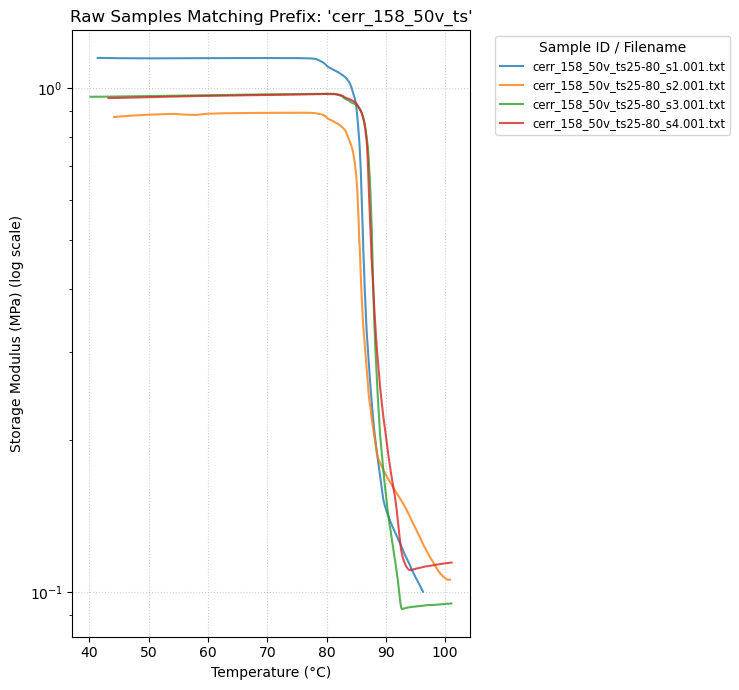

In [2]:
# === Imports ===
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# === Configuration ===
# IMPORTANT: Set the base directory where ss0, ss80, ts folders reside
BASE_DIR = Path(r'D:\Guien MEMS Lab Final\new_method') # Use raw string for Windows paths

# Define the column indices (adjust if your format differs)
COL_MAP = {
    'Strain': 9,
    'Stress': 4,
    'Temperature': 1,
    'Storage Modulus': 2,
}
VALID_TEST_TYPES = ['ss0', 'ss80', 'ts']

# === Helper Functions (Keep these defined) ===

def parse_sample_id(filename_str):
    """Extracts sample ID (e.g., 's1', 's2') from the filename."""
    try:
        base_name = filename_str.removesuffix('.txt')
        parts = base_name.split('_')
        for part in reversed(parts):
            if part.startswith('s') and len(part) > 1 and part[1:].isdigit():
                return part
        warnings.warn(f"Could not find standard sample ID ('s#') in {filename_str}. No label assigned.")
        return None
    except Exception as e:
        warnings.warn(f"Error parsing sample ID from {filename_str}: {e}")
        return None

def read_data_file(filepath):
    """Reads the DMA data file, skipping header and extracting numeric data."""
    data_lines = []
    in_data_section = False
    encodings_to_try = ['utf-16', 'utf-8-sig', 'latin-1']

    for encoding in encodings_to_try:
        try:
            with open(filepath, 'r', encoding=encoding) as f:
                data_lines = []
                in_data_section = False
                for line in f:
                    stripped_line = line.strip()
                    if not stripped_line: continue
                    if stripped_line == 'StartOfData':
                        in_data_section = True
                        continue
                    if in_data_section:
                        try:
                            vals = stripped_line.split()
                            data_row = [float(val) for val in vals]
                            data_lines.append(data_row)
                        except ValueError:
                            warnings.warn(f"[{encoding}] Skipping non-numeric data row in {filepath.name}: '{stripped_line}'")
                            continue

            if data_lines:
                num_cols_first = len(data_lines[0])
                consistent_data = [row for row in data_lines if len(row) == num_cols_first]
                if len(consistent_data) != len(data_lines):
                     warnings.warn(f"[{encoding}] Inconsistent column counts in {filepath.name}. Using {len(consistent_data)} rows.")
                if not consistent_data:
                     warnings.warn(f"[{encoding}] No consistent data rows found in {filepath.name}.")
                     return None
                return np.array(consistent_data) # Success

        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            warnings.warn(f"File not found: {filepath}. Skipping.")
            return None
        except Exception as e:
            warnings.warn(f"Error reading {filepath} with {encoding}: {e}")

    warnings.warn(f"Could not read data from {filepath.name} with any attempted encoding.")
    return None


# === Main Plotting Logic ===


# <<< --- EDIT THIS LINE to change which files are plotted --- >>>
file_prefix = "cerr_158_50v_ts" # Example: Plot all samples for cerr_117 10v ss0
# file_prefix = "ecoflex_50_ts"      # Example: Plot all samples for ecoflex_50 ts
# <<< --------------------------------------------------------- >>>

print(f"Attempting to plot files starting with: '{file_prefix}'")

# 1. Infer Test Type and Validate Input
test_type = None
try:
    prefix_parts = file_prefix.split('_')
    potential_test_type = prefix_parts[-1].lower()
    if potential_test_type in VALID_TEST_TYPES:
        test_type = potential_test_type
    else:
         raise ValueError(f"Inferred test type '{potential_test_type}' from end of prefix is not valid.")
except (IndexError, ValueError) as e:
    print(f"Error: Could not determine a valid test type ('ss0', 'ss80', 'ts') from the end of the prefix '{file_prefix}'.")
    print(f"Details: {e}")
    print(f"Please ensure the prefix ends with one of: {', '.join(VALID_TEST_TYPES)}")
    # In Jupyter, we might not want to exit, just stop this cell's execution flow
    raise SystemExit("Stopping due to invalid prefix.") # Or just `pass` if you want notebook to continue

# 2. Determine Target Directory and Plot Parameters
target_dir = BASE_DIR / test_type / 'export'
if not target_dir.is_dir():
    print(f"Error: Directory not found based on inferred test type '{test_type}': {target_dir}")
    raise SystemExit(f"Stopping. Directory not found: {target_dir}")

if test_type in ['ss0', 'ss80']:
    x_col_name, y_col_name = 'Strain', 'Stress'
    x_label, y_label = 'Strain (%)', 'Stress (MPa)'
else: # test_type == 'ts'
    x_col_name, y_col_name = 'Temperature', 'Storage Modulus'
    x_label, y_label = 'Temperature (°C)', 'Storage Modulus (MPa)'

try:
    x_col_idx = COL_MAP[x_col_name]
    y_col_idx = COL_MAP[y_col_name]
except KeyError as e:
    print(f"Error: Column name '{e}' not found in COL_MAP configuration.")
    raise SystemExit(f"Stopping. Column '{e}' not in COL_MAP.")


# 3. Find Matching Files and Plot
print(f"Searching for files starting with '{file_prefix}' in '{target_dir}'...")

fig, ax = plt.subplots(figsize=(9, 7))
files_found = 0
files_plotted = 0

for filepath in target_dir.glob(f'{file_prefix}*.txt'):
    if filepath.name.startswith(file_prefix) and filepath.name.endswith('.txt'):
        files_found += 1
        print(f"  Processing: {filepath.name}")

        sample_id = parse_sample_id(filepath.name)
        plot_label = sample_id if sample_id else filepath.name # Use filename if ID fails

        raw_data = read_data_file(filepath)
        if raw_data is None or raw_data.shape[0] == 0:
            continue

        try:
            if raw_data.shape[1] <= max(x_col_idx, y_col_idx):
                raise IndexError(f"Not enough columns (Needed max index {max(x_col_idx, y_col_idx)}, Found:{raw_data.shape[1]})")

            x_raw = raw_data[:, x_col_idx]
            y_raw = raw_data[:, y_col_idx]

            is_finite = np.isfinite(x_raw) & np.isfinite(y_raw)
            x = x_raw[is_finite]
            y = y_raw[is_finite]

            if len(x) < 2:
                warnings.warn(f"    Skipping {filepath.name} (label: {plot_label}): Not enough valid data points (< 2).")
                continue

            sort_idx = np.argsort(x)
            x_plot = x[sort_idx]
            y_plot = y[sort_idx]

            ax.plot(x_plot, y_plot, '-', label=plot_label, alpha=0.8)
            files_plotted += 1

        except IndexError as e:
            warnings.warn(f"    Skipping {filepath.name} (label: {plot_label}): Error accessing columns - {e}.")
            continue
        except Exception as plot_err:
             warnings.warn(f"    Error processing/plotting data for {filepath.name} (label: {plot_label}): {plot_err}")
             continue

# 4. Finalize and Show Plot
print(f"\nFound {files_found} files potentially matching prefix.")
if files_plotted > 0:
    print(f"Plotting data for {files_plotted} samples.")
    ax.set_title(f"Raw Samples Matching Prefix: '{file_prefix}'")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(title='Sample ID / Filename', fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside plot

    # Add log scale for TS plots if data seems appropriate (optional)
    if test_type == 'ts':
        try:
            all_y_data = []
            for line in ax.get_lines():
                ydata = line.get_ydata()
                finite_y = ydata[np.isfinite(ydata)]
                if len(finite_y) > 0: all_y_data.extend(finite_y)
            if all_y_data and np.all(np.array(all_y_data) > 1e-9):
                ax.set_yscale('log')
                ax.set_ylabel(f"{y_label} (log scale)")
        except Exception as log_e:
             warnings.warn(f"Could not evaluate/set log scale: {log_e}")

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for external legend
    plt.show()
else:
    print(f"No valid data found to plot for files starting with '{file_prefix}' in {target_dir}.")
    # Optionally close the empty plot if nothing was plotted
    plt.close(fig)